# US-002：核心数据结构 — Raw → Epochs → Evoked

**目标：** 深入理解 MNE 三个核心数据对象及其转换关系，能手写代码模拟整个流程。

**关键流程：** `Raw`（连续数据）→ `Epochs`（事件切分）→ `Evoked`（平均）

## 1. 手写 NumPy 创建 Raw 对象

真正理解 Raw 的最好方式——自己造一个。

In [11]:
import numpy as np
import mne

# ---------- 参数 ----------
sfreq = 250           # 采样率 250 Hz
n_channels = 8        # 8 个 EEG 通道
duration = 60         # 60 秒
n_times = sfreq * duration
print(f"采样点数: {n_times}")

# ---------- 模拟 EEG 数据 ----------
# 每个通道：10Hz alpha 振荡 + 随机噪声
t = np.arange(n_times) / sfreq
print(f"时间轴: {t}")

data = np.zeros((n_channels, n_times))
for ch in range(n_channels):
    alpha = 50e-6 * np.sin(2 * np.pi * 10 * t)          # 10 Hz alpha
    noise = 20e-6 * np.random.randn(n_times)             # 高斯噪声
    data[ch] = alpha + noise

# ---------- 创建 Info ----------
ch_names = [f'EEG {i:03d}' for i in range(1, n_channels + 1)]
print(f"通道名称: {ch_names}")


ch_types = ['eeg'] * n_channels
print(f"通道类型: {ch_types}")

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
print(f"Info: {info}")


采样点数: 15000
时间轴: [0.0000e+00 4.0000e-03 8.0000e-03 ... 5.9988e+01 5.9992e+01 5.9996e+01]
通道名称: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
通道类型: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
Info: <Info | 7 non-empty values
 bads: []
 ch_names: EEG 001, EEG 002, EEG 003, EEG 004, EEG 005, EEG 006, EEG 007, ...
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 250.0 Hz
>


In [ ]:
for ch in info['chs']:
    for key, value in ch.items():
        print(f"{key}: {value}")
    print("-----------------")


4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 90 unique labels.


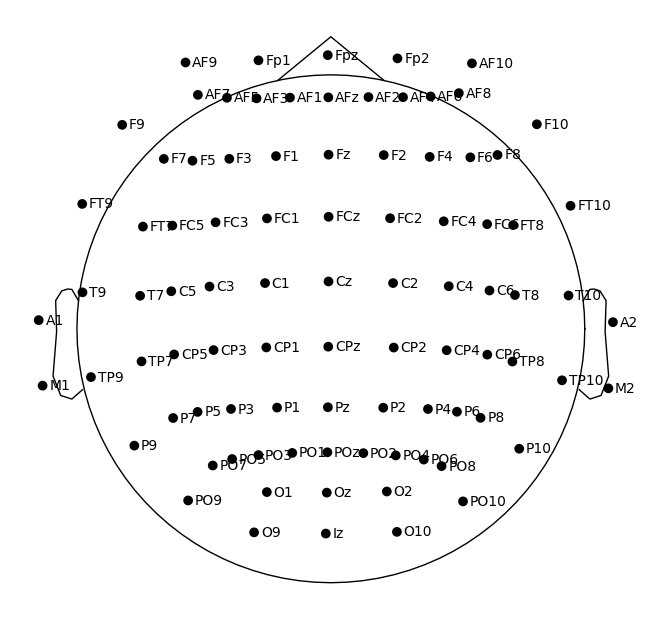

['Fp1', 'Fpz', 'Fp2', 'AF9', 'AF7', 'AF5', 'AF3', 'AF1', 'AFz', 'AF2']
['AF4', 'AF6', 'AF8', 'AF10', 'F9', 'F7', 'F5', 'F3', 'F1', 'Fz']
['F2', 'F4', 'F6', 'F8', 'F10', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1']
['FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T9', 'T7', 'C5', 'C3']
['C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'T10', 'TP9', 'TP7', 'CP5']
['CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P9', 'P7']
['P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO9']
['PO7', 'PO5', 'PO3', 'PO1', 'POz', 'PO2', 'PO4', 'PO6', 'PO8', 'PO10']
['O1', 'Oz', 'O2', 'O9', 'Iz', 'O10', 'T3', 'T5', 'T4', 'T6']
['M1', 'M2', 'A1', 'A2']


In [12]:
# 添加标准 10-20 蒙太奇（电极位置）
montage: mne.channels.DigMontage = mne.channels.make_standard_montage('standard_1020')
montage.plot()
# 每10个电极名称打印一行
for i in range(0, len(montage.ch_names), 10):
    print(montage.ch_names[i:i+10])


标准10-20系统的电极位置是和**大脑解剖位置**一一对应的。你必须知道你的 `EEG 001` 到底贴在头皮的哪个位置。

常见对应关系可以参考：
| 位置描述 | 标准名称 |
| :--- | :--- |
| 前额左/右 | Fp1 / Fp2 |
| 额叶左/右 | F3 / F4 |
| 中央左/右 | C3 / C4 |
| 顶叶左/右 | P3 / P4 |
| 枕叶左/右 | O1 / O2 |
| 额叶中线 | Fz |
| 中央中线 | Cz |
| 顶叶中线 | Pz |

In [ ]:

# 重命名通道
# 假设你的数据有8个通道，电极实际放置位置已知
# 格式：{'旧名称': '新标准名称'}
mapping = {
    'EEG 001': 'Fp1',
    'EEG 002': 'Fp2',
    'EEG 003': 'C3',
    'EEG 004': 'C4',
    'EEG 005': 'O1',
    'EEG 006': 'O2',
    'EEG 007': 'Fz',
    'EEG 008': 'Cz'
}

# 1. 重命名通道（添加防止重复rename的判断）
if not all(new_name in info['ch_names'] for new_name in mapping.values()):
    info.rename_channels(mapping)

# 2. 验证名称是否改过来了
print(info['ch_names'])
# 输出: ['Fp1', 'Fp2', 'C3', 'C4', 'O1', 'O2', 'Fz', 'Cz']

['Fp1', 'Fp2', 'C3', 'C4', 'O1', 'O2', 'Fz', 'Cz']


In [21]:
# 设置通道位置
info.set_montage(montage)
print(info['ch_names'])

# ---------- 创建 Raw ----------
raw: mne.io.RawArray = mne.io.RawArray(data, info)
print(raw)
print(f"数据形状: {raw.get_data().shape}")  # (n_channels, n_times)
print(raw.info)

['Fp1', 'Fp2', 'C3', 'C4', 'O1', 'O2', 'Fz', 'Cz']
Creating RawArray with float64 data, n_channels=8, n_times=15000
    Range : 0 ... 14999 =      0.000 ...    59.996 secs
Ready.
<RawArray | 8 x 15000 (60.0 s), ~952 KiB, data loaded>
数据形状: (8, 15000)
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, C3, C4, O1, O2, Fz, Cz
 chs: 8 EEG
 custom_ref_applied: False
 dig: 11 items (3 Cardinal, 8 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 250.0 Hz
>


In [22]:
for ch in info['chs']:  # 不加切片，遍历全部
    print(f"{ch['ch_name']}: {ch['loc'][:3]}")

Fp1: [-0.0309026   0.11458518  0.02786657]
Fp2: [0.02840949 0.11534631 0.02772126]
C3: [-0.06714873  0.02335823  0.10451068]
C4: [0.06532887 0.0235731  0.10369243]
O1: [-0.03157357 -0.08056835  0.05478965]
O2: [ 0.02768309 -0.08048884  0.05473408]
Fz: [-0.00122928  0.09327445  0.10263929]
Cz: [-0.00137414  0.02761709  0.14019949]


In [44]:
montage_positions = info.get_montage().get_positions()
for ch_name, pos in montage_positions['ch_pos'].items():
    print(f"{ch_name}: {pos}")

Fp1: [-0.0309026   0.11458518  0.02786657]
Fp2: [0.02840949 0.11534631 0.02772126]
C3: [-0.06714873  0.02335823  0.10451068]
C4: [0.06532887 0.0235731  0.10369243]
O1: [-0.03157357 -0.08056835  0.05478965]
O2: [ 0.02768309 -0.08048884  0.05473408]
Fz: [-0.00122928  0.09327445  0.10263929]
Cz: [-0.00137414  0.02761709  0.14019949]


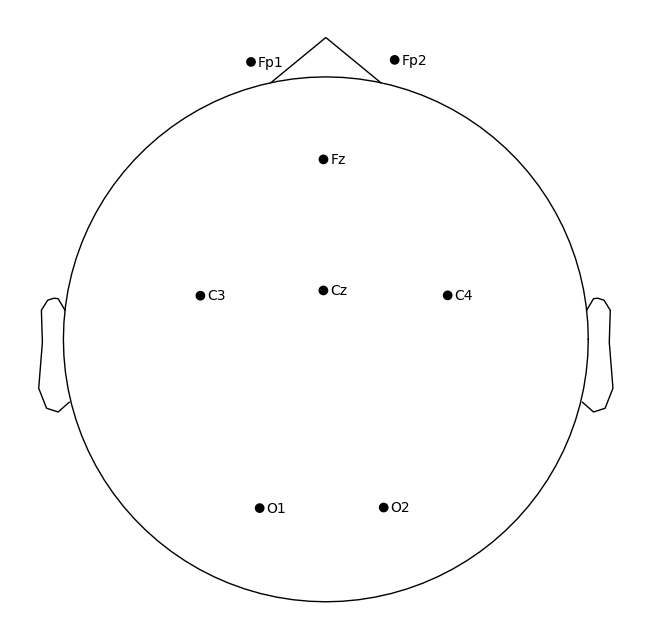

['Fp1', 'Fp2', 'C3', 'C4', 'O1', 'O2', 'Fz', 'Cz']


In [111]:
info_montage = info.get_montage()
fig = info_montage.plot()
print(info_montage.ch_names)


In [45]:
montage_positions = info.get_montage().get_positions()
for ch_name in info['ch_names']:
    if ch_name in montage_positions['ch_pos']:
        print(f"✓ {ch_name}: 已定位")
    else:
        print(f"✗ {ch_name}: 未找到位置")

✓ Fp1: 已定位
✓ Fp2: 已定位
✓ C3: 已定位
✓ C4: 已定位
✓ O1: 已定位
✓ O2: 已定位
✓ Fz: 已定位
✓ Cz: 已定位


## 2. 创建 Events（事件标记）

Events 是 M x 3 的整数数组，每行 `[onset_sample, duration, event_id]`。

In [ ]:
# 模拟：每秒出现一个事件，交替 event_id = 1 和 event_id = 2
event_onsets = np.arange(0, n_times, sfreq).astype(int)  # 每秒一个
event_ids = np.tile([1, 2], len(event_onsets) // 2 + 1)[:len(event_onsets)]
durations = np.zeros(len(event_onsets), dtype=int)
print(f"事件时间点: {event_onsets}") # 每秒一个事件
print(f"事件 ID: {event_ids}")
print(f"事件持续时间: {durations}")


事件时间点: [    0   250   500   750  1000  1250  1500  1750  2000  2250  2500  2750
  3000  3250  3500  3750  4000  4250  4500  4750  5000  5250  5500  5750
  6000  6250  6500  6750  7000  7250  7500  7750  8000  8250  8500  8750
  9000  9250  9500  9750 10000 10250 10500 10750 11000 11250 11500 11750
 12000 12250 12500 12750 13000 13250 13500 13750 14000 14250 14500 14750]
事件 ID: [1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]
事件持续时间: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [77]:

events = np.column_stack([event_onsets, durations, event_ids])
print(f"事件数组形状: {events.shape}")
print(f"事件总数: {len(events)}")
print(f"前 5 个事件:\n{events[:5]}")



事件数组形状: (60, 3)
事件总数: 60
前 5 个事件:
[[   0    0    1]
 [ 250    0    2]
 [ 500    0    1]
 [ 750    0    2]
 [1000    0    1]]


## 3. 从 Raw 创建 Epochs — 数据切分

Epochs 是按事件切出来的固定时间窗口片段。
`tmin` 和 `tmax` 定义窗口相对于事件 onset 的时间范围。

In [92]:
# 切出 -200ms 到 800ms 的片段
tmin, tmax = -0.2, 0.8  # 0.2 秒前到 0.8 秒后

# 事件 ID 映射
event_id = {'condition_A': 1, 'condition_B': 2}

# 切出 Epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=(None, 0),        # 以事件前为基线
    preload=True,               # 加载到内存
    reject=None,                # 暂不拒绝坏段
    verbose=False
)
print(epochs)
# 第一个事件被丢弃是 MNE 的正常行为，用来保证所有 epoch 都有完整的基线数据。
# print(epochs.events)

print(f"Epochs 数据形状: {epochs.get_data().shape}")  # (n_epochs, n_channels, n_times)
print(f"时间点: {epochs.times[:5]} ... {epochs.times[-5:]}")

<Epochs | 59 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~940 KiB, data loaded,
 'condition_A': 29
 'condition_B': 30>
Epochs 数据形状: (59, 8, 251)
时间点: [-0.2   -0.196 -0.192 -0.188 -0.184] ... [0.784 0.788 0.792 0.796 0.8  ]


### 3.1 按条件索引 Epochs

用事件 ID 字典中的 key 快速选取子集。

In [96]:
epochs_A = epochs['condition_A']
epochs_B = epochs['condition_B']
print(f"条件 A Epochs 数: {len(epochs_A)}")
print(f"条件 B Epochs 数: {len(epochs_B)}")
print(epochs)
print(epochs_A)
print(epochs_B)

条件 A Epochs 数: 29
条件 B Epochs 数: 30
<Epochs | 59 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~940 KiB, data loaded,
 'condition_A': 29
 'condition_B': 30>
<Epochs | 29 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~469 KiB, data loaded,
 'condition_A': 29>
<Epochs | 30 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~485 KiB, data loaded,
 'condition_B': 30>


## 4. Evoked — 对 Epochs 做平均

`Evoked` 对象 = 某个条件下的平均 ERP 波形。这是事件相关电位（ERP）分析的核心。

为什么要平均？

|目的|说明|
|------|------|
|增强信噪比|	真正的 ERP 信号在每次 trial 中一致，随机噪声不一致，平均后噪声抵消|
|提取锁时响应|	保留与事件时间锁定的神经活动（ERP），去除不相关的自发脑电|
|得到代表性波形|	单个 trial 波动大，平均后得到该条件下的典型响应|


In [98]:
# 对每个条件分别做平均
evoked_A = epochs_A.average()
evoked_B = epochs_B.average()

print("Evoked A:", evoked_A)
print("Evoked B:", evoked_B)
print(f"\nEvoked 数据形状: {evoked_A.data.shape}")  # (n_channels, n_times)
print(f"\n时间点: {evoked_A.times[:5]} ... {evoked_A.times[-5:]}")
print(f"\nEvoked 数据形状: {evoked_B.data.shape}")  # (n_channels, n_times)
print(f"\n时间点: {evoked_B.times[:5]} ... {evoked_B.times[-5:]}")


Evoked A: <Evoked | 'condition_A' (average, N=29), -0.2 – 0.8 s, baseline -0.2 – 0 s, 8 ch, ~30 KiB>
Evoked B: <Evoked | 'condition_B' (average, N=30), -0.2 – 0.8 s, baseline -0.2 – 0 s, 8 ch, ~30 KiB>

Evoked 数据形状: (8, 251)

时间点: [-0.2   -0.196 -0.192 -0.188 -0.184] ... [0.784 0.788 0.792 0.796 0.8  ]

Evoked 数据形状: (8, 251)

时间点: [-0.2   -0.196 -0.192 -0.188 -0.184] ... [0.784 0.788 0.792 0.796 0.8  ]


### 4.1 可视化 Evoked — 蝴蝶图

蝴蝶图（butterfly plot）把所有通道的 ERP 波形叠在一张图上。

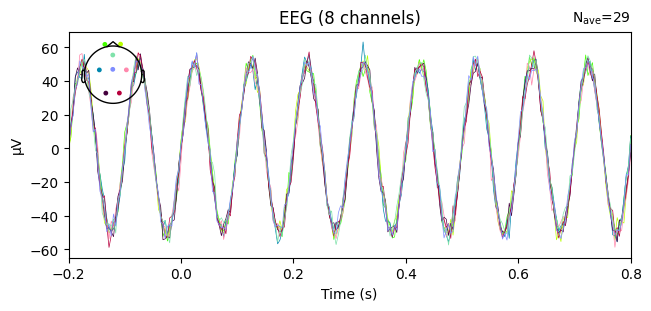

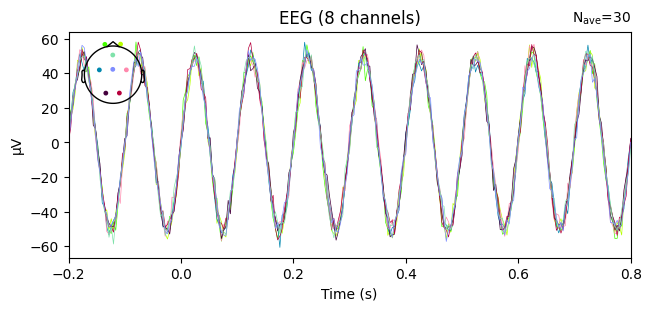

In [100]:
# 绘制条件 A 的蝴蝶图
fig = evoked_A.plot(spatial_colors=True)
fig = evoked_B.plot(spatial_colors=True)


## 5. 数据流转总结

```
Raw (n_channels, n_times)                 连续原始数据
  │
  │  + Events 数组 + tmin/tmax
  ▼
Epochs (n_epochs, n_channels, n_times)    事件切分的小段
  │
  │  .average()
  ▼
Evoked (n_channels, n_times)              平均 ERP 波形
```

## 6. 练习

1. 修改模拟数据的频率（加 20Hz beta），观察 ERP 的变化
2. 尝试不同的 `tmin`/`tmax`，理解窗口大小对 Epochs 的影响
3. 对比 `baseline=(None, 0)` 和 `baseline=(-0.2, 0)` 的区别